In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("outputs/figures", exist_ok=True)

In [4]:
columns = (
    ["engine_id", "cycle"] +
    [f"setting_{i}" for i in range(1, 4)] +
    [f"sensor_{i}" for i in range(1, 22)]
)

train_raw = pd.read_csv(
    "../data/train_FD001.txt",
    sep=r"\s+",
    header=None
)

train_raw.columns = columns

print(train_raw.shape)
train_raw.head()

(20631, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
train = train_raw.copy()

max_cycle = train.groupby("engine_id")["cycle"].max()
train["RUL"] = train["engine_id"].map(max_cycle) - train["cycle"]

train[["engine_id", "cycle", "RUL"]].head()

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [6]:
all_sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
print(all_sensor_cols)

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


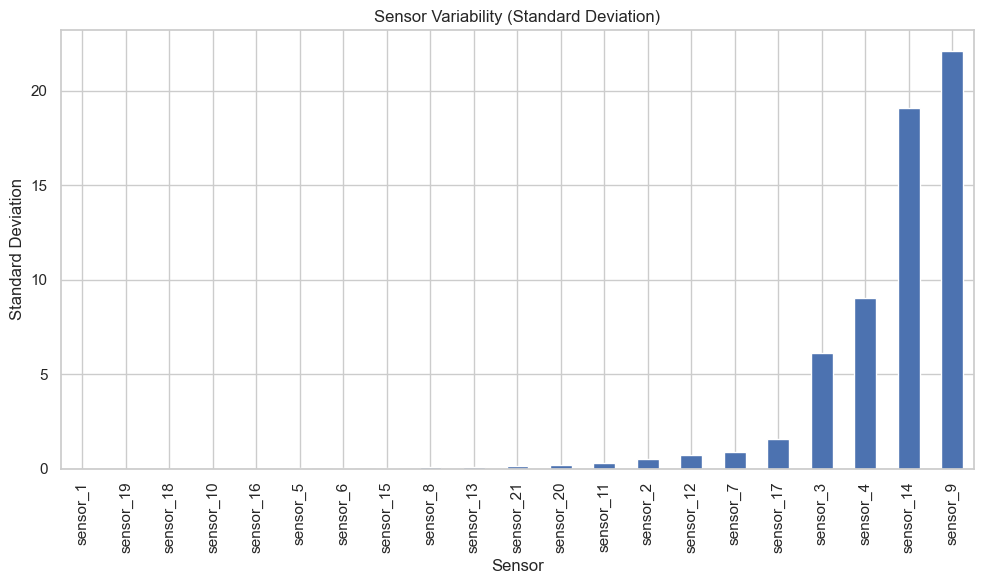

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    1.387812e-17
sensor_5     1.776400e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

In [7]:
sensor_std = train[all_sensor_cols].std().sort_values()

plt.figure(figsize=(10, 6))
sensor_std.plot(kind="bar")
plt.title("Sensor Variability (Standard Deviation)")
plt.ylabel("Standard Deviation")
plt.xlabel("Sensor")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("outputs/figures/sensor_variability.png", dpi=300)
plt.show()

sensor_std

In [8]:
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train = train.drop(columns=constant_sensors).copy()

In [9]:
print(train.shape)

(20631, 21)


In [10]:
sensor_cols = [col for col in train.columns if col.startswith("sensor_")]

print(len(sensor_cols))
print(sensor_cols)

15
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


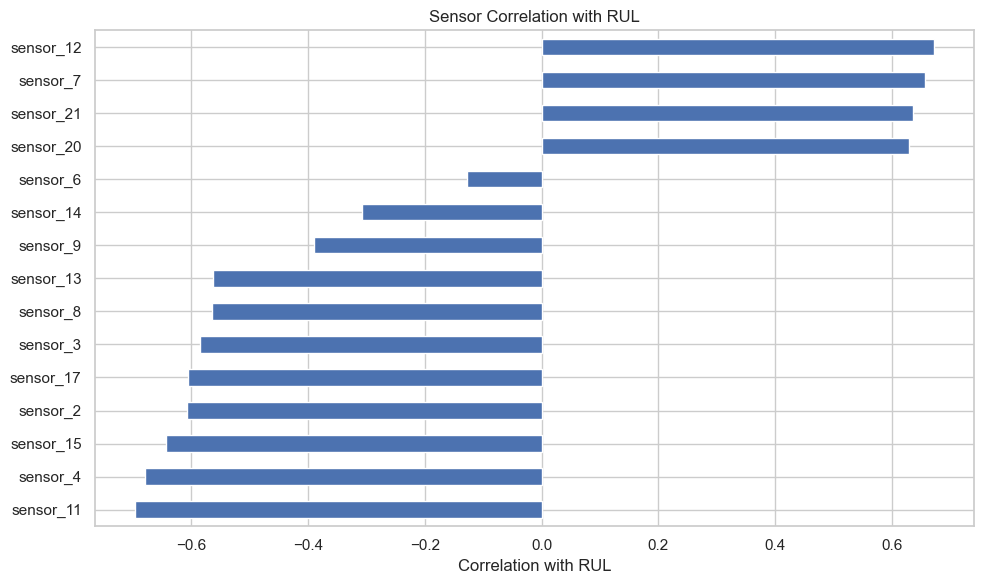

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
Name: RUL, dtype: float64

In [11]:
corr_with_rul = train[sensor_cols + ["RUL"]].corr()["RUL"].drop("RUL")

corr_sorted = corr_with_rul.sort_values()

plt.figure(figsize=(10,6))
corr_sorted.plot(kind="barh")
plt.title("Sensor Correlation with RUL")
plt.xlabel("Correlation with RUL")

plt.tight_layout()
plt.savefig("outputs/figures/sensor_rul_correlation.png", dpi=300)
plt.show()

corr_sorted

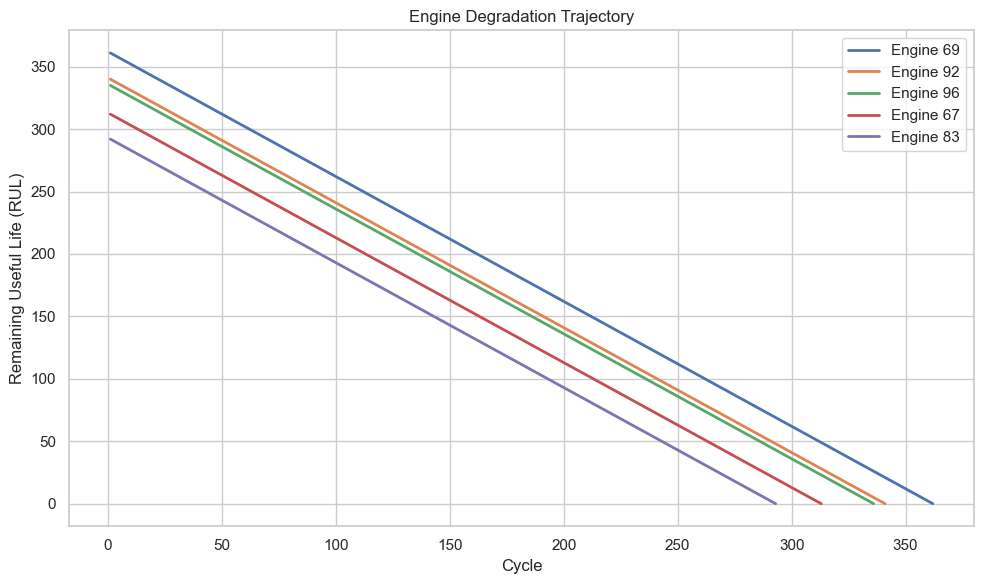

In [12]:
engine_cycles = train.groupby("engine_id")["cycle"].max()

sample_engines = engine_cycles.sort_values(ascending=False).head(5).index.tolist()

plt.figure(figsize=(10,6))

for eng in sample_engines:
    temp = train[train["engine_id"] == eng]
    plt.plot(temp["cycle"], temp["RUL"], linewidth=2, label=f"Engine {eng}")

plt.title("Engine Degradation Trajectory")
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("outputs/figures/engine_degradation_trajectory.png", dpi=300)
plt.show()

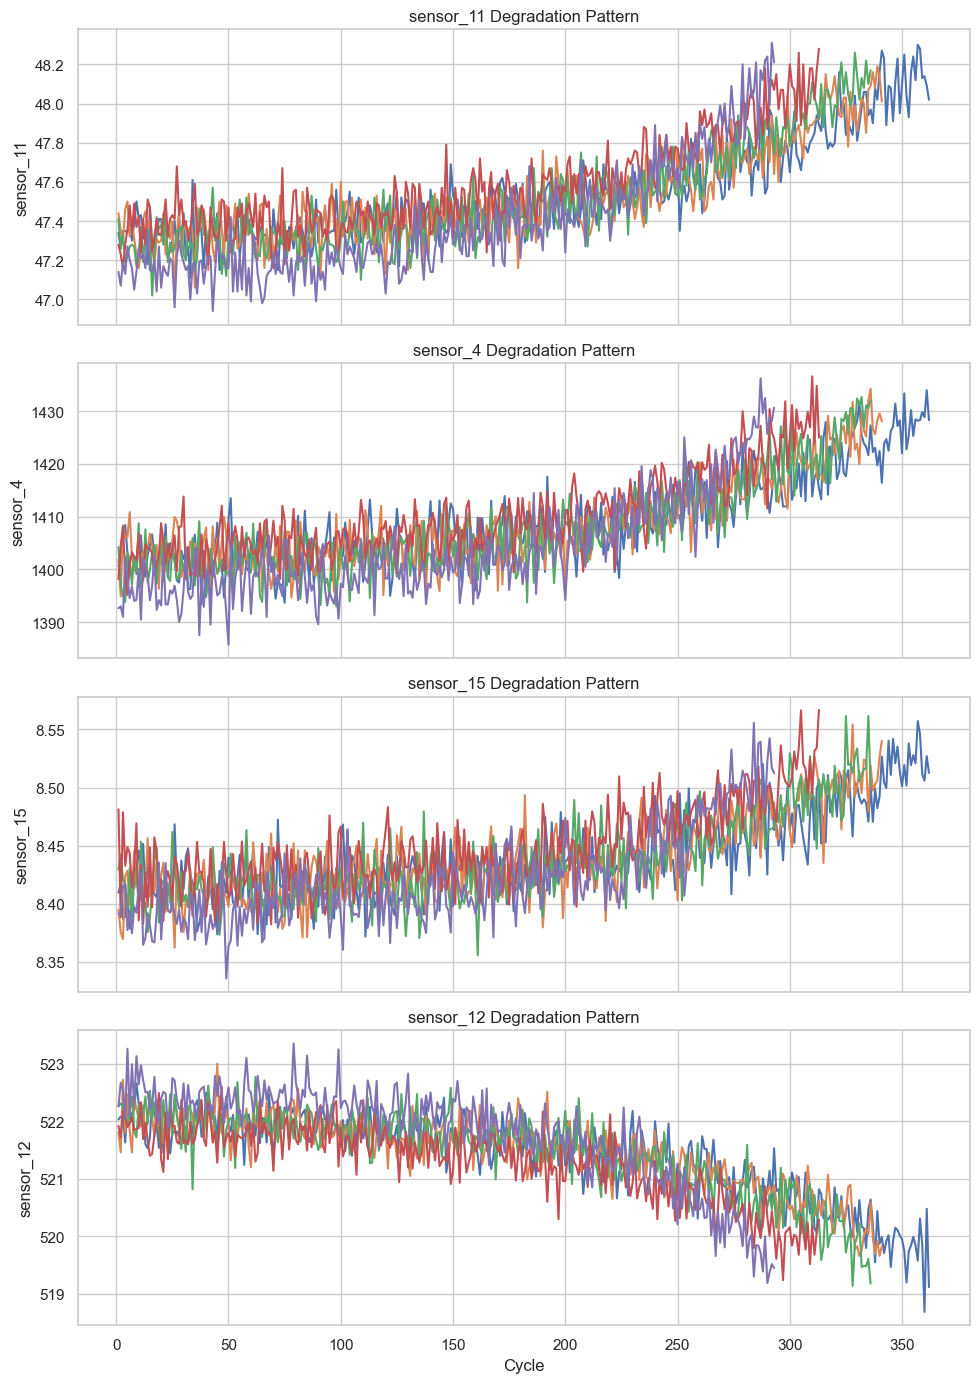

In [13]:
important_sensors = ["sensor_11","sensor_4","sensor_15","sensor_12"]

sample = train[train["engine_id"].isin(sample_engines)]

fig, axes = plt.subplots(len(important_sensors),1, figsize=(10,14), sharex=True)

for i,sensor in enumerate(important_sensors):
    for eng in sample_engines:
        temp = sample[sample["engine_id"] == eng]
        axes[i].plot(temp["cycle"], temp[sensor])
    axes[i].set_title(f"{sensor} Degradation Pattern")
    axes[i].set_ylabel(sensor)

axes[-1].set_xlabel("Cycle")

plt.tight_layout()
plt.savefig("outputs/figures/sensor_degradation_patterns.png", dpi=300)
plt.show()

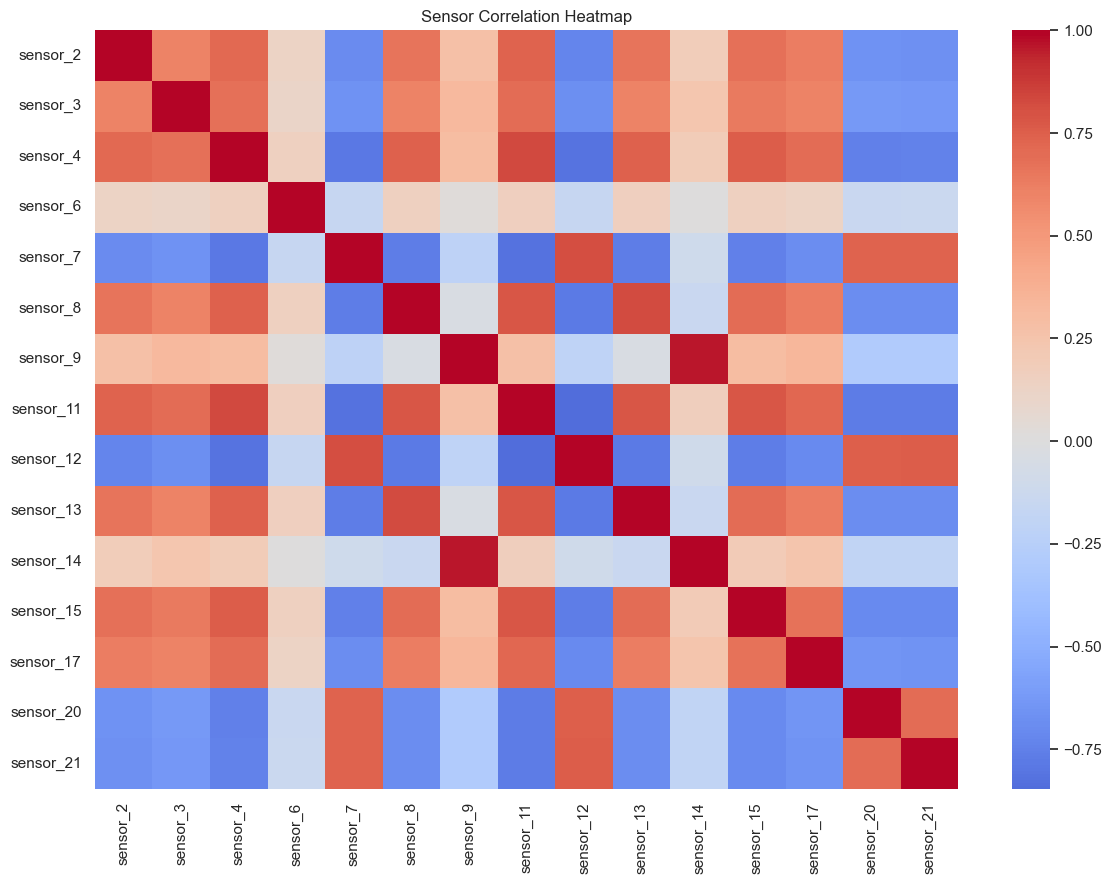

In [14]:
corr_matrix = train[sensor_cols].corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Sensor Correlation Heatmap")

plt.tight_layout()
plt.savefig("outputs/figures/sensor_correlation_heatmap.png", dpi=300)
plt.show()

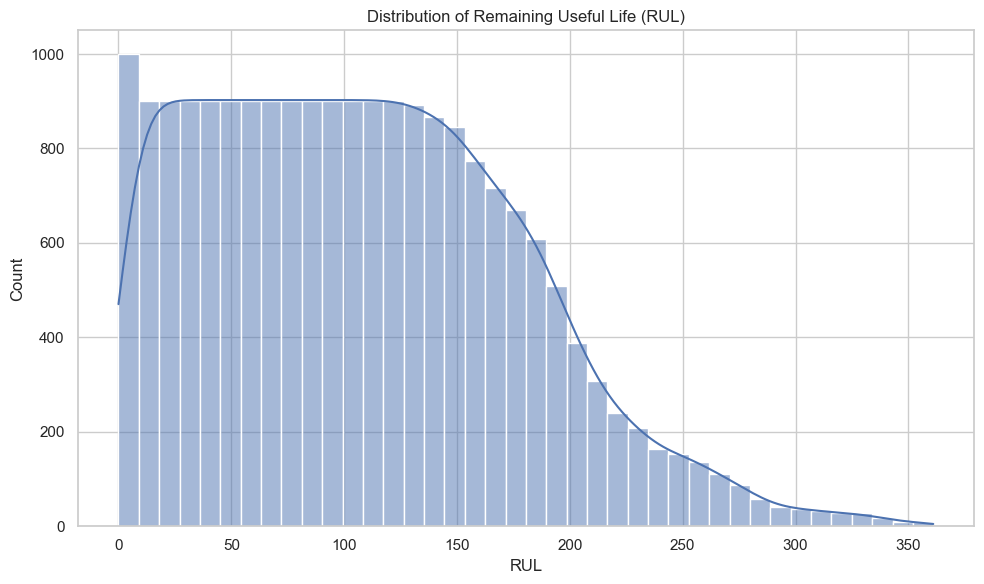

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(train["RUL"], bins=40, kde=True)

plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("outputs/figures/rul_distribution.png", dpi=300)
plt.show()

In [16]:
train_model = train.copy()

print(train_model.shape)

(20631, 21)


In [17]:
window = 5

for col in sensor_cols:

    train_model[f"{col}_rolling_mean"] = (
        train_model.groupby("engine_id")[col]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    train_model[f"{col}_rolling_std"] = (
        train_model.groupby("engine_id")[col]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )

In [18]:
for col in sensor_cols:
    train_model[f"{col}_diff"] = train_model.groupby("engine_id")[col].diff()

In [19]:
train_model = train_model.dropna().copy()

print(train_model.shape)

(20231, 66)


In [20]:
feature_cols = [
    col for col in train_model.columns
    if col not in ["engine_id", "cycle", "RUL"]
]

X = train_model[feature_cols]
y = train_model["RUL"]

print(X.shape)

(20231, 63)


In [21]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    test_size=0.2,
    n_splits=1,
    random_state=42
)

train_idx, val_idx = next(gss.split(X, y, groups=train_model["engine_id"]))

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

print(X_train.shape, X_val.shape)

(16241, 63) (3990, 63)


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

pred_val = rf.predict(X_val)

rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))

print("Validation RMSE:", rmse_val)

Validation RMSE: 33.47361832171576


In [24]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 모델들 정의
models = {
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=10, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, max_depth=10, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=200, depth=10, random_state=42, verbose=False)
}

# 각 모델 학습 및 평가
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
    results[name] = rmse_val
    print(f"{name} Validation RMSE: {rmse_val:.4f}")

# 결과 출력
print("\n=== 모델 비교 결과 ===")
for name, rmse in results.items():
    print(f"{name}: {rmse:.4f}")

# 가장 좋은 모델 선택
best_model_name = min(results, key=results.get)
best_rmse = results[best_model_name]
print(f"\n가장 좋은 모델: {best_model_name} (RMSE: {best_rmse:.4f})")

# 가장 좋은 모델로 최종 모델 설정
if best_model_name == 'RandomForest':
    final_model = models['RandomForest']
elif best_model_name == 'XGBoost':
    final_model = models['XGBoost']
elif best_model_name == 'LightGBM':
    final_model = models['LightGBM']
else:
    final_model = models['CatBoost']

# 최종 모델 재학습 (전체 훈련 데이터 사용)
final_model.fit(X, y)
print(f"\n최종 모델 ({best_model_name})을 전체 데이터로 재학습 완료")

RandomForest Validation RMSE: 33.4736
XGBoost Validation RMSE: 36.5753
LightGBM Validation RMSE: 34.1043
CatBoost Validation RMSE: 35.2622

=== 모델 비교 결과 ===
RandomForest: 33.4736
XGBoost: 36.5753
LightGBM: 34.1043
CatBoost: 35.2622

가장 좋은 모델: RandomForest (RMSE: 33.4736)

최종 모델 (RandomForest)을 전체 데이터로 재학습 완료


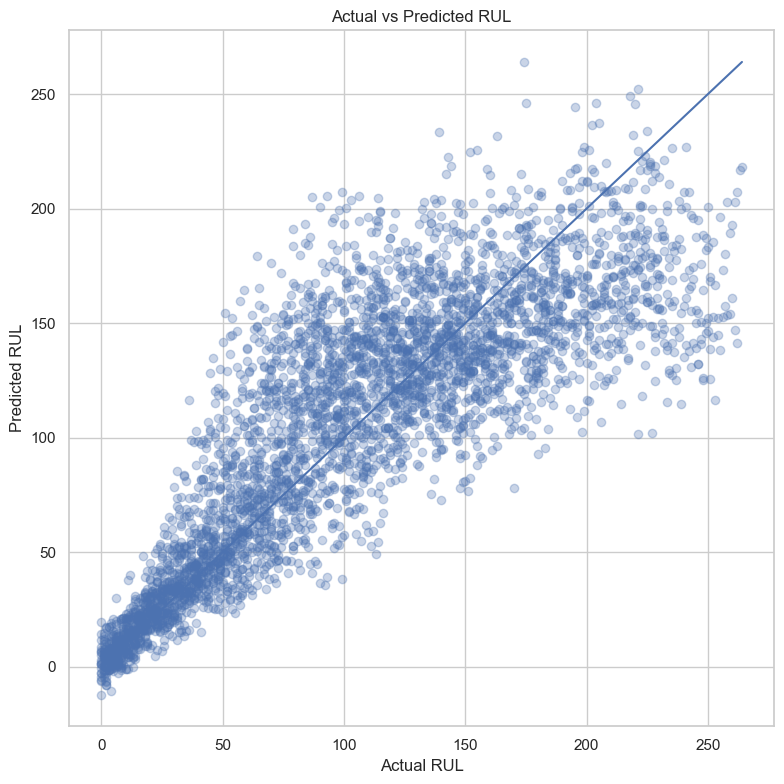

In [25]:
plt.figure(figsize=(8,8))

plt.scatter(y_val, pred_val, alpha=0.3)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()]
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig("outputs/figures/prediction_vs_actual.png", dpi=300)

plt.show()

In [27]:
columns = (
    ["engine_id", "cycle"] +
    [f"setting_{i}" for i in range(1, 4)] +
    [f"sensor_{i}" for i in range(1, 22)]
)

test = pd.read_csv(
    "../data/test_FD001.txt",
    sep=r"\s+",
    header=None
)

test = test.iloc[:, :26]
test.columns = columns

print(test.shape)

(13096, 26)


In [28]:
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

test = test.drop(columns=constant_sensors).copy()

print(test.shape)

(13096, 20)


In [29]:
test_model = test.copy()

window = 5

for col in sensor_cols:

    test_model[f"{col}_rolling_mean"] = (
        test_model.groupby("engine_id")[col]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    test_model[f"{col}_rolling_std"] = (
        test_model.groupby("engine_id")[col]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )

for col in sensor_cols:
    test_model[f"{col}_diff"] = test_model.groupby("engine_id")[col].diff()

test_model = test_model.dropna().copy()

In [30]:
test_last = test_model.groupby("engine_id").tail(1).copy()

print(test_last.shape)

(100, 65)


In [31]:
X_test = test_last[feature_cols]

test_last["predicted_RUL"] = rf.predict(X_test)

test_last["predicted_RUL"].describe()

count    100.000000
mean      94.958426
std       55.862857
min        4.544706
25%       46.856719
50%      102.900704
75%      139.611180
max      241.039701
Name: predicted_RUL, dtype: float64

In [33]:
rul_test = pd.read_csv("../data/RUL_FD001.txt", header=None)

rul_test.columns = ["true_RUL"]

test_last = test_last.sort_values("engine_id").reset_index(drop=True)

test_last["true_RUL"] = rul_test["true_RUL"]

In [34]:
rmse_test = np.sqrt(
    mean_squared_error(
        test_last["true_RUL"],
        test_last["predicted_RUL"]
    )
)

print("Test RMSE:", rmse_test)

Test RMSE: 34.632410869179935


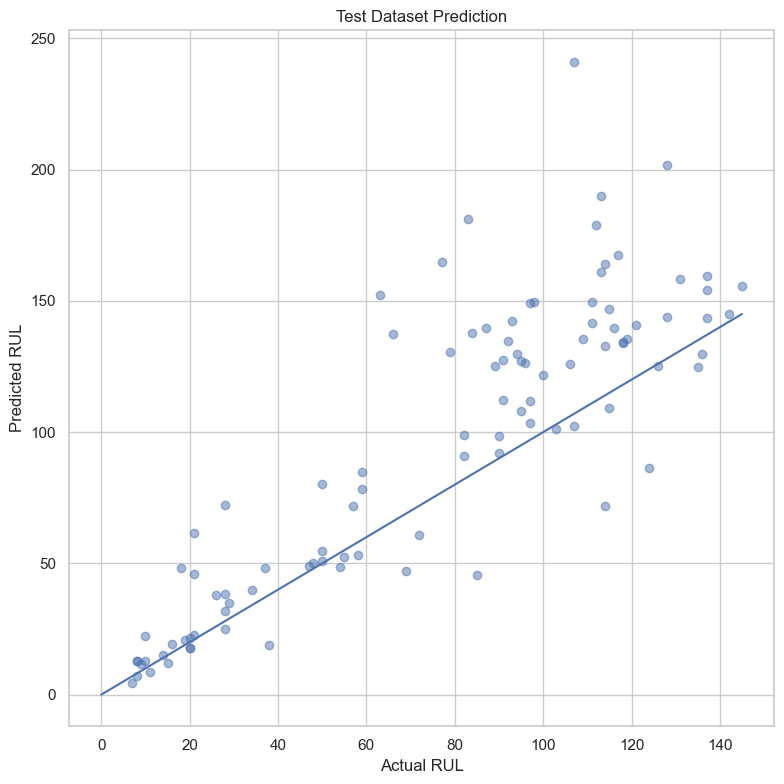

In [35]:
plt.figure(figsize=(8,8))

plt.scatter(
    test_last["true_RUL"],
    test_last["predicted_RUL"],
    alpha=0.5
)

plt.plot(
    [0, max(test_last["true_RUL"])],
    [0, max(test_last["true_RUL"])]
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("Test Dataset Prediction")

plt.tight_layout()

plt.savefig("outputs/figures/test_prediction_vs_actual.png", dpi=300)

plt.show()

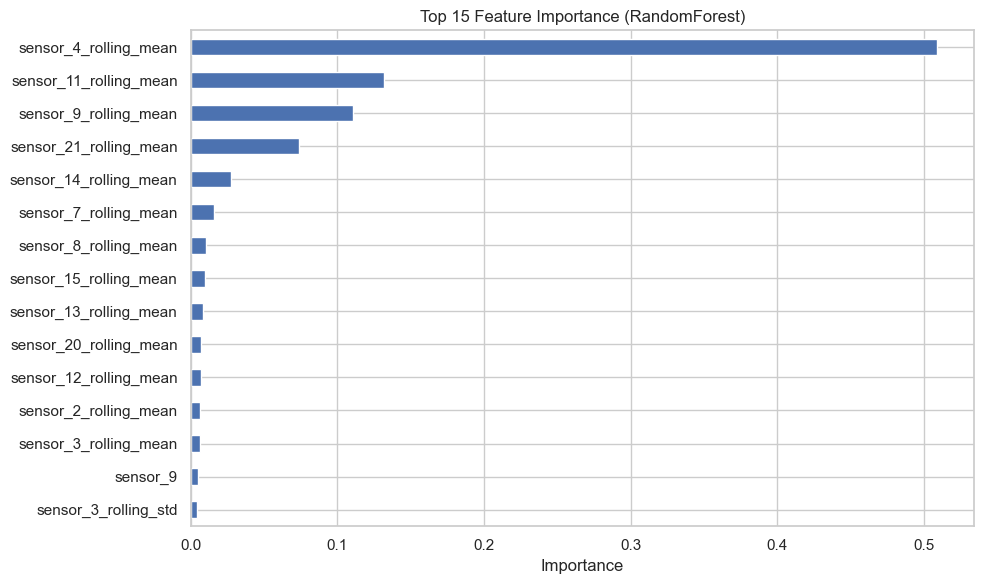

sensor_4_rolling_mean     0.508925
sensor_11_rolling_mean    0.132020
sensor_9_rolling_mean     0.110284
sensor_21_rolling_mean    0.073409
sensor_14_rolling_mean    0.027451
sensor_7_rolling_mean     0.015922
sensor_8_rolling_mean     0.010311
sensor_15_rolling_mean    0.009642
sensor_13_rolling_mean    0.008562
sensor_20_rolling_mean    0.007088
sensor_12_rolling_mean    0.006761
sensor_2_rolling_mean     0.006478
sensor_3_rolling_mean     0.006050
sensor_9                  0.004650
sensor_3_rolling_std      0.004030
dtype: float64

In [36]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top15 = importance.head(15)

plt.figure(figsize=(10,6))

top15.sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importance (RandomForest)")
plt.xlabel("Importance")

plt.tight_layout()

plt.savefig("outputs/figures/feature_importance.png", dpi=300)

plt.show()

top15

In [37]:
fleet_risk = test_last[["engine_id", "predicted_RUL"]].copy()

fleet_risk = fleet_risk.sort_values("predicted_RUL").reset_index(drop=True)

fleet_risk.head(15)

,engine_id,predicted_RUL
0,34,4.544706
1,81,7.026905
2,35,8.487194
3,82,11.666456
4,56,12.069777
5,68,12.672296
6,76,12.735234
7,31,12.882048
8,66,14.905218
9,92,17.670301


In [38]:
def risk_level(rul):
    if rul < 20:
        return "High"
    elif rul < 50:
        return "Medium"
    else:
        return "Low"

fleet_risk["risk_level"] = fleet_risk["predicted_RUL"].apply(risk_level)

fleet_risk.head(15)

,engine_id,predicted_RUL,risk_level
0,34,4.544706,High
1,81,7.026905,High
2,35,8.487194,High
3,82,11.666456,High
4,56,12.069777,High
5,68,12.672296,High
6,76,12.735234,High
7,31,12.882048,High
8,66,14.905218,High
9,92,17.670301,High


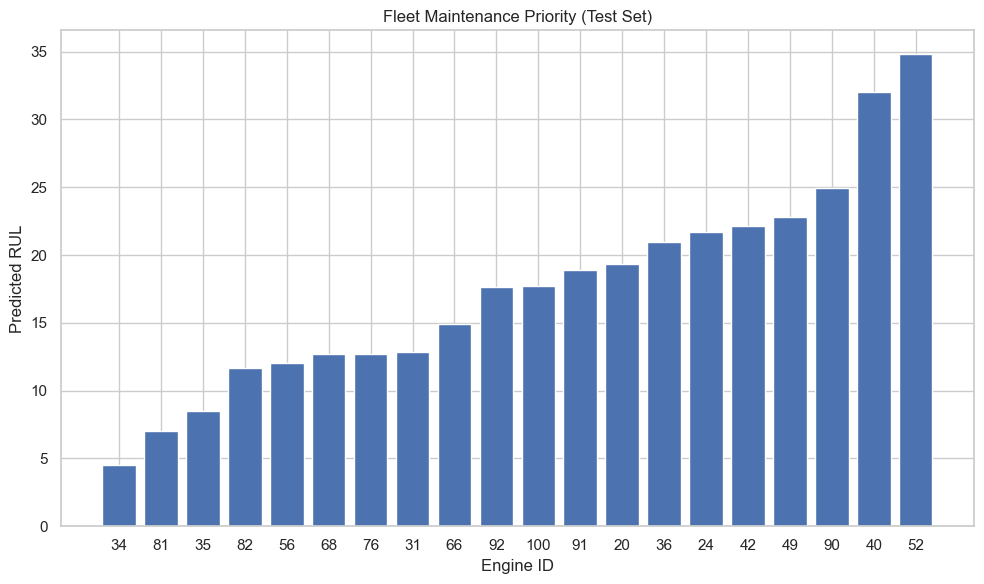

In [39]:
plt.figure(figsize=(10,6))

top_risk = fleet_risk.head(20)

plt.bar(
    top_risk["engine_id"].astype(str),
    top_risk["predicted_RUL"]
)

plt.xlabel("Engine ID")
plt.ylabel("Predicted RUL")

plt.title("Fleet Maintenance Priority (Test Set)")

plt.tight_layout()

plt.savefig("outputs/figures/fleet_risk_ranking.png", dpi=300)

plt.show()

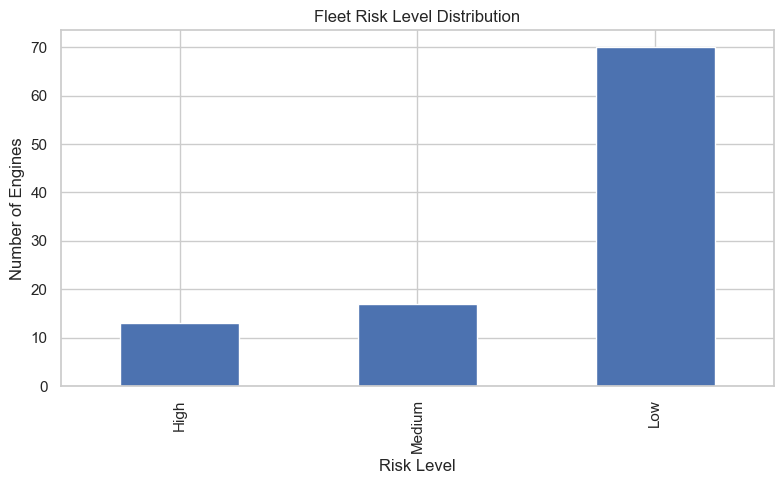

In [40]:
risk_counts = fleet_risk["risk_level"].value_counts().reindex(["High","Medium","Low"])

plt.figure(figsize=(8,5))

risk_counts.plot(kind="bar")

plt.title("Fleet Risk Level Distribution")

plt.xlabel("Risk Level")
plt.ylabel("Number of Engines")

plt.tight_layout()

plt.savefig("outputs/figures/fleet_risk_distribution.png", dpi=300)

plt.show()

In [41]:
fleet_risk.to_csv("outputs/fleet_risk_table.csv", index=False)

test_last[["engine_id","true_RUL","predicted_RUL"]].to_csv(
    "outputs/test_predictions.csv",
    index=False
)

top15.to_csv("outputs/feature_importance.csv")